**data cleaning.** 

in dit document zullen we een kort laten zien hoe ik een document ga cleanen. hieronder zullen dus mijn opties zichtbaar worden.

natuurlijk is het belangrijk dat we beginnen met de files weldegelijk op te roepen zodat we er kunnne met cleanen. Met df.info zullen we gaan kijken hoeveel keer per kolom er niks is ingevuld in dat vlak.

wij zullen hiervoor ook isnull().sum() gebruiken. dit gaat kijken hoeveel lege rijen er zijn voor die specifieke colommen. met dit kunne we checken als er tabellen zijn met veel lege rijen of niet.

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv('../csv/train/train_CarBreakDown.csv')

df.isnull().sum()


id                            0
vehicle_brand                21
vehicle_age_years            16
mileage_km                   17
engine_hours                 15
last_service_km_ago          10
oil_quality_pct              36
avg_trip_length_km           12
weather_exposure             13
fuel_type                    14
cleanliness_score            55
driver_satisfaction_score    13
tyre_type                    17
breakdown_next_30_days        0
dtype: int64

**vehicle_brand**

Het eerste wat we direct kunnen zien door de file in te lezen, is dat er voertuigen zijn waarvoor geen merk is ingevuld (NaN). Het merk van een auto kan belangrijk zijn voor de data, want als er iets gebeurt met een auto, kunnen we nagaan bij welk merk dat het vaakst voorkomt.

**Wat doen we met NaN-records?**

De beste keuze is om alle rijen met een niet ingevuld merk te verwijderen uit het document. Natuurlijk is er ook de optie om de kolom vehicle_brand volledig uit de file te verwijderen.

**Is de kolom nodig?**

Ik denk dat voor onze use case – bepalen of een auto binnen 30 dagen kapot gaat of niet – het vrij belangrijk is dat we het automerk kennen. Elk automerk is anders en daar moet rekening mee worden gehouden. In vergelijking met een reductie van 2% is dat, denk ik, niet zo erg. We verliezen dan niet heel veel, in tegenstelling tot wanneer we een hele kolom zouden verwijderen.

In [84]:
df = df.dropna(subset=['vehicle_brand'])

df.head()

df.isnull().sum()


id                            0
vehicle_brand                 0
vehicle_age_years            16
mileage_km                   17
engine_hours                 15
last_service_km_ago           9
oil_quality_pct              36
avg_trip_length_km           12
weather_exposure             13
fuel_type                    14
cleanliness_score            52
driver_satisfaction_score    13
tyre_type                    17
breakdown_next_30_days        0
dtype: int64

bij het verwijderen van de Nan zien we ook dat voor ook een paar andere kolommer gegevens van zijn verwijderd. we hebben voor deze

**vehicle_age_years**

zoals we kunnen zien blijven er nog steeds hetzelfde aantal lege rijen voor vehicle_age_years.

**wat nu**

je kunt hier natuurlijk ook weer de optie te pakken om deze rijen te verwijderen, maar niks meegeven kan ook een teken zijn van dat deze auto's nog minder dan een jaar in gebruik zijn. natuurlijk is hier geen bewijs van.

**hoe gaan we het doen**

we kunnen dit bekijken door de volgende tabel te gebruiken mileage_km. in de code hieronder zullen we voor alle NaN gegevens bekijken als deze een mileage hebben.


In [85]:
missing_age = df[df['vehicle_age_years'].isna()]

# Toon enkel id en vehicle_age_years
missing_age[['id', 'vehicle_age_years', 'mileage_km']]

,id,vehicle_age_years,mileage_km
92,421,NaN,232693.390285
127,962,NaN,137256.857613
130,1235,NaN,213681.103300
159,513,NaN,70290.889246
212,164,NaN,137565.695202
304,1373,NaN,129748.512326
310,942,NaN,159270.622800
408,869,NaN,89691.261723
414,448,NaN,242489.213895
440,1202,NaN,110041.046804


aan de mileage kunnen we zien dat de rijen die leeg zijn een mileage hebben. meeste van deze zijn aan de grotere kant dus het is bijna onmogelijk om de kms te halen in onder een jaar.

hier kiezen we dus ook om al deze rijen te verwijderen. voor de resterende informatie kunnen we ook direct de vraag stellen als er een directe link is tussen de leeftijd van een auto en het merk

**grafiek**

hiervoor zullen we een boxplot gebruiken om het is te bekijken. een boxplot is hiervoor beter aangezien het gemiddekde heel hard omlaag/omhoog kan getrokken door auto's die maar een jaar of 25 jaar oud zijn. 

<Figure size 1000x600 with 0 Axes>

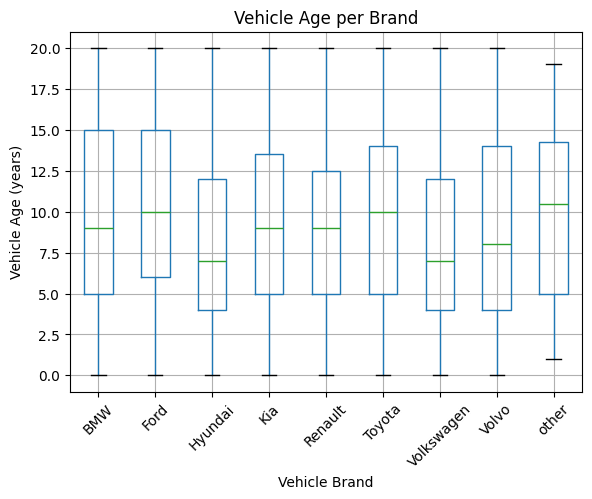

id                            0
vehicle_brand                 0
vehicle_age_years             0
mileage_km                   17
engine_hours                 15
last_service_km_ago           9
oil_quality_pct              35
avg_trip_length_km            9
weather_exposure             13
fuel_type                    13
cleanliness_score            52
driver_satisfaction_score    12
tyre_type                    17
breakdown_next_30_days        0
dtype: int64

In [86]:


df = df.dropna(subset=['vehicle_age_years'])
plt.figure(figsize=(10,6))
df.boxplot(column='vehicle_age_years', by='vehicle_brand')
plt.xticks(rotation=45)
plt.title('Vehicle Age per Brand')
plt.suptitle('')
plt.xlabel('Vehicle Brand')
plt.ylabel('Vehicle Age (years)')
plt.show()

df.isnull().sum()


**mileage_km**

zoals we weer kunnen zien zijn er autos waar de mileage niet van is geweten

**hoe**

we kunnen hier zoals gewoonlijk de keuze maken om deze rijen te verwijderen. dit zorgt ervoor dat er geen autos zijn die geen mileage zouden hebben.

er is hier ook de optie om deze gegevens zelf in te vullen we kunnen dit doen door te gaan bekijken als er een link is tussen de mileage en hoeveel jaar de auto al rijd.

zoals hierboven ook zichtbaar is zijn de getallen aan de grotere kant. voor de gemakkelijkheid gaan we deze getallen afronden 

**belangrijk?**

de KMs zijn enorm belangrijk voor de eindata aangezien veel auto's kapot gaan door een groot aantal km op hun voertuig. dus de lijnen met geen mileage kan niet de reden voor de breakdown geweten zijn. ik kies dus om voor deze gegevens. om te beginnen zullen we eerst zien dat er een groot verschil is tussen median en gemiddelde per jaar


In [ ]:
df['mileage_km'] = df['mileage_km'].round()
df.head()


    vehicle_age_years          mean    median
0                 0.0  1.179631e+05  120036.0
1                 1.0  1.486930e+05  130917.0
2                 2.0  9.529710e+06  113985.5
3                 3.0  4.785729e+06  141588.0
4                 4.0  7.595729e+06  118077.0
5                 5.0  1.720182e+06  115018.0
6                 6.0  1.463525e+05  112322.0
7                 7.0  6.289501e+06  118394.0
8                 8.0  1.342394e+05  128808.0
9                 9.0  1.094391e+07  130838.0
10               10.0  2.358771e+06  114474.0
11               11.0  6.441860e+06  122272.5
12               12.0  1.481673e+05  125456.0
13               13.0  3.227943e+06  114456.0
14               14.0  3.846780e+06  122676.0
15               15.0  1.769656e+06  115505.5
16               16.0  2.517297e+06  119774.0
17               17.0  1.425981e+05  136794.5
18               18.0  5.315322e+06  128410.5
19               19.0  3.444881e+06  116293.5
20               20.0  6.113815e+0